In [1]:
%load_ext autoreload
%autoreload 2


from collections import defaultdict
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import HTML, display
import os
import sys
import glob 
from acpype.topol import ACTopol, MolTopol
sys.path.append(os.path.abspath('../')) 
import param_tool as pt
import py3Dmol
import MDAnalysis as mda
import nglview as nv
from parmed import amber, gromacs
import json
from pathlib import Path

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

In [2]:
def file_opener(path, sanitize=True, verbose=False):
    name = Path(path).stem
    extension = Path(path).suffix.lower()
    match extension:
        case ".smi" | ".smiles":
            rdkit_mol = pt.smi_to_chem(path, addH=True, sanitize=sanitize,
                                       format_coord='2D')
        case ".mol2":
            rdkit_mol = pt.mol2_to_chem(path, removeHs=False, sanitize=sanitize,
                                        format_coord='2D', verbose=verbose)
        case ".pdb":
            rdkit_mol = pt.pdb_to_chem(path, removeHs=False, sanitize=sanitize,
                                       format_coord='2D')
        case _:
            raise TypeError(f"Неподдерживаемый тип: {extension}")
    return rdkit_mol

In [164]:
def hdb_generator(mol_chem, resname='MOD', resid=1, segid='A'):
    """
    Принимает на вход:
     - mol путь к файлу или rdkit.Chem объект
    Модифицирует имена атомов в молекуле по правилам аминокислот:
    - N, H, CA, C, O имеют стандартные имена
    - Боковые атомы получают буквенные метки по греческому алфавиту
    - Протоны наследуют имя родительского атома и получают числовой суффикс
    """
    def find_common_prefix(strings):
        if not strings:
            return ""

        first = strings[0]
        for i in range(len(first), 0, -1):
            prefix = first[:i]
            if all(s.startswith(prefix) for s in strings[1:]):
                return prefix
        return ""

    hdb = ['1	1	H	N	-C	CA	\n',
           '1	5	HA	CA	N	CB	C\n']
    
    for atom in mol_chem.GetAtoms():
        if atom.GetSymbol() == 'H':
            continue
        current_idx = atom.GetIdx()
        current_atom_name = atom.GetProp('AtomName')
        protons = []
        visited_atoms = {current_atom_name: current_idx}
        for n_atom in atom.GetNeighbors():
            atom_name = n_atom.GetProp('AtomName')
            atom_idx = n_atom.GetIdx()
            if n_atom.GetSymbol() != "H":
                visited_atoms[atom_name] = atom_idx
            elif n_atom.GetProp('AtomName') not in ['H','HA', 'HN']:
                protons.append(atom_name)
        if not protons:  # У атома нет протонов идем к слежующему атому
            continue
        # Если H на атоме с валентностью 2
        if len(visited_atoms) == 2:  # Будет только 1 тяжелый сосед
            atom_2 = mol_chem.GetAtomWithIdx(min(visited_atoms.values()))
            # # Берем индекс соседа и находим его соседа с наименьшим индексом
            atom_3 = min(filter(lambda n: n.GetSymbol() != "H" and
                                n.GetIdx() not in visited_atoms.values(), atom_2.GetNeighbors()),
                         key=lambda n: n.GetIdx(), default=None)
            if atom_3:
                atom_3_name = atom_3.GetProp('AtomName')
                atom_3_idx = atom_3.GetIdx()
                visited_atoms[atom_3_name] = atom_3_idx

        hyb = atom.GetHybridization()
        n_hydrogens = len(protons)
        n_heavy_neighbors = int(atom.GetDegree()) - n_hydrogens
        if hyb == Chem.HybridizationType.SP3:
            if n_hydrogens == 1 and n_heavy_neighbors == 3:
                geom_n = 5  # sp3 углерод с 1 протоном
            elif n_hydrogens == 2 and n_heavy_neighbors == 2:
                geom_n = 6  # sp3 углерод с 2 протоном
            elif n_hydrogens == 3 and n_heavy_neighbors == 1:
                geom_n = 4  # sp3 углерод с 3 протоном
            elif n_hydrogens == 1 and n_heavy_neighbors == 1:
                geom_n = 2  # sp3 углерод с 1 протоном
            else:
                print(f"Не учтенный вариант {atom.GetProp('AtomName')}:",
                     f"{name}, {hyb}, {n_hydrogens}, {n_heavy_neighbors}", sep='\n')
                geom_n = '-'
        elif hyb == Chem.HybridizationType.SP2:
            if n_hydrogens == 1 and n_heavy_neighbors == 2:
                geom_n = 1
            elif n_hydrogens == 2 and n_heavy_neighbors == 1:
                geom_n = 3
            elif n_hydrogens == 1 and n_heavy_neighbors == 1:
                geom_n = 2
            else:
                print(f"Не учтенный вариант {atom.GetProp('AtomName')}:",
                     f"{name}, {hyb}, {n_hydrogens}, {n_heavy_neighbors}", sep='\n')
                geom_n = '-'
        else:
            if protons:
                print("Существуют не описанные протоны:")
                print(atom.GetProp("AtomName"), hyb)
                print(protons)
                geom_n = '-'
            
        if protons: # ['H'] ['HB1', 'HB2'] ['HC1', 'HC2', 'HC3']
            # print(protons)
            n_H = str(len(protons))
            H_name = find_common_prefix(protons)
            if H_name not in ['H', 'HA', 'HN']:
                hdb.append("{}\t{}\t{}\t{}\n".format(n_H, geom_n, H_name, "\t".join(visited_atoms)))
                # ['CB', 'CA', 'CG'] ['CK', 'CI'] ['CA', 'N', 'C', 'CB']
    # print(heavy_atoms)
    hdb = [f'{resname}\t{len(hdb)}\n'] + hdb
    return hdb
    #     print(neighbors, sep = '\n')
    # print(heavy_atoms)

In [125]:

test_mol = glob.glob('*.mol2')
chem_dict ={}
# test_mol = ['CIR.mol2', 'THIC.mol2']
# for mol in test_mol:
#     print(mol)
mol = 'L_sidechain_copy/6CL/6CL.mol2'
mol_dict = file_opener(mol, sanitize=True, verbose = False)
(name, chem), = mol_dict.items()
chem = pt.renumber_amino_acid_atoms(chem)
chem_dict[name] = chem
pt.draw_mol_with_atom_index(chem)

gen_hdb = hdb_generator(chem, name)

save_path = f"{name}_gen.hdb"
with open(save_path, 'w') as dat:
    dat.writelines(gen_hdb)

### Проверка протокола создания hdb на датасете SwissSidechain L-amino acids	

In [165]:
mol2_list = glob.glob('L_sidechain_copy/*/*.mol2')
chem_dict ={}
# test_mol = ['CIR.mol2', 'THIC.mol2']
for mol in mol2_list[:]:
    print(mol)
    # mol = 'L_sidechain_copy/NIY/NIY.mol2'

    mol_dict = file_opener(mol, sanitize=True, verbose = False)

    (name, chem), = mol_dict.items()
    if not chem:
        continue
    chem = pt.renumber_amino_acid_atoms(chem)
    chem_dict[name] = chem

    gen_hdb = hdb_generator(chem, name)
    save_path = f"L_sidechain_copy/{name}/{name}_gen.hdb"
    with open(save_path, 'w') as dat:
        dat.writelines(gen_hdb)

L_sidechain_copy/4HMP/4HMP.mol2
L_sidechain_copy/PFF/PFF.mol2
L_sidechain_copy/SME/SME.mol2
L_sidechain_copy/PYR2/PYR2.mol2
L_sidechain_copy/TPO/TPO.mol2
L_sidechain_copy/HOX/HOX.mol2
L_sidechain_copy/MHO/MHO.mol2
L_sidechain_copy/2HF/2HF.mol2
L_sidechain_copy/6CL/6CL.mol2
L_sidechain_copy/QU34/QU34.mol2
L_sidechain_copy/NAO2/NAO2.mol2
L_sidechain_copy/CCS/CCS.mol2
L_sidechain_copy/ILX/ILX.mol2
L_sidechain_copy/2HF2/2HF2.mol2
L_sidechain_copy/TFLE/TFLE.mol2
L_sidechain_copy/BHD/BHD.mol2
L_sidechain_copy/ESC/ESC.mol2
L_sidechain_copy/VAH/VAH.mol2
L_sidechain_copy/26P/26P.mol2
Существуют не описанные протоны:
N UNSPECIFIED
['HN1', 'HN2', 'HN3']
Существуют не описанные протоны:
CB UNSPECIFIED
['HB2', 'HB1']
Существуют не описанные протоны:
CG UNSPECIFIED
['HG1', 'HG2']
Существуют не описанные протоны:
CD UNSPECIFIED
['HD1', 'HD2']
L_sidechain_copy/OBF/OBF.mol2
L_sidechain_copy/DDZ/DDZ.mol2
L_sidechain_copy/CHP/CHP.mol2
L_sidechain_copy/CHG/CHG.mol2
L_sidechain_copy/MEG/MEG.mol2
L_sidechai

[17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[17:57:14] sanitize [17:57:14] 2HF.pdb: [17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 8 9
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] sanitize [17:57:14] 26P.pdb: [17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 12
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 14
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13


L_sidechain_copy/4BF/4BF.mol2
L_sidechain_copy/TTQ/TTQ.mol2
L_sidechain_copy/QU32/QU32.mol2
L_sidechain_copy/4FW/4FW.mol2
L_sidechain_copy/PYR3/PYR3.mol2
L_sidechain_copy/GME/GME.mol2
L_sidechain_copy/HLU/HLU.mol2
L_sidechain_copy/TRO/TRO.mol2
L_sidechain_copy/HSER/HSER.mol2
L_sidechain_copy/THA3/THA3.mol2
L_sidechain_copy/TFG4/TFG4.mol2
L_sidechain_copy/LME/LME.mol2
L_sidechain_copy/ME0/ME0.mol2
L_sidechain_copy/HL2/HL2.mol2
L_sidechain_copy/APD/APD.mol2
L_sidechain_copy/PHI/PHI.mol2
L_sidechain_copy/2AG/2AG.mol2
L_sidechain_copy/OMY/OMY.mol2
L_sidechain_copy/BTH3/BTH3.mol2
L_sidechain_copy/F2F/F2F.mol2
L_sidechain_copy/2FM/2FM.mol2
L_sidechain_copy/NAL/NAL.mol2
L_sidechain_copy/YCM/YCM.mol2
L_sidechain_copy/AZDA/AZDA.mol2
L_sidechain_copy/TPO2/TPO2.mol2
L_sidechain_copy/BIU/BIU.mol2
L_sidechain_copy/TFG2/TFG2.mol2
L_sidechain_copy/FPG4/FPG4.mol2
L_sidechain_copy/OMX/OMX.mol2
L_sidechain_copy/CPG3/CPG3.mol2
L_sidechain_copy/MP34/MP34.mol2
L_sidechain_copy/BUG/BUG.mol2
L_sidechain_copy

[17:57:14] Can't kekulize mol.  Unkekulized atoms: 3 4 6 7 8 9 10 11 12
[17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] sanitize [17:57:14] 2NP.pdb: [17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] Explicit valence for atom # 8 C, 5, is greater than permitted
[17:57:14] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:14] sanitize [17:57:14] CIR.pdb: [17:57:14] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:14] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10


L_sidechain_copy/LEF/LEF.mol2
L_sidechain_copy/ABA/ABA.mol2
L_sidechain_copy/2AS/2AS.mol2
L_sidechain_copy/FGL/FGL.mol2
L_sidechain_copy/STYA/STYA.mol2
L_sidechain_copy/AHB/AHB.mol2
L_sidechain_copy/WFP/WFP.mol2
L_sidechain_copy/CP34/CP34.mol2
L_sidechain_copy/FCL/FCL.mol2
L_sidechain_copy/4PH/4PH.mol2
L_sidechain_copy/FLA/FLA.mol2
L_sidechain_copy/0A1/0A1.mol2
L_sidechain_copy/HIL4/HIL4.mol2
L_sidechain_copy/I2M/I2M.mol2
L_sidechain_copy/FTR/FTR.mol2
L_sidechain_copy/PPN/PPN.mol2
L_sidechain_copy/OLT/OLT.mol2
L_sidechain_copy/MTR6/MTR6.mol2
L_sidechain_copy/TRX/TRX.mol2
L_sidechain_copy/2HF1/2HF1.mol2
L_sidechain_copy/DIPH/DIPH.mol2
L_sidechain_copy/LE1/LE1.mol2
L_sidechain_copy/LMQ/LMQ.mol2
L_sidechain_copy/HTR/HTR.mol2
L_sidechain_copy/ONL/ONL.mol2
L_sidechain_copy/FUA2/FUA2.mol2
L_sidechain_copy/CPA3/CPA3.mol2
L_sidechain_copy/SEP/SEP.mol2
L_sidechain_copy/MEN/MEN.mol2
L_sidechain_copy/HQA/HQA.mol2
L_sidechain_copy/HRP/HRP.mol2
L_sidechain_copy/ALN/ALN.mol2


[17:57:14] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8 9 10 11 12
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13
[17:57:14] Explicit valence for atom # 11 C, 5, is greater than permitted
[17:57:14] sanitize [17:57:14] APM.pdb: [17:57:14] Explicit valence for atom # 11 C, 5, is greater than permitted
[17:57:14] Explicit valence for atom # 11 C, 5, is greater than permitted
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 13 14
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 14
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[17:57:14] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 12 13 14
[17:57:14] Can't kekulize mol.  

L_sidechain_copy/MEQ/MEQ.mol2
L_sidechain_copy/4CF/4CF.mol2
L_sidechain_copy/GDPR/GDPR.mol2
L_sidechain_copy/PYR4/PYR4.mol2
L_sidechain_copy/LDO/LDO.mol2
L_sidechain_copy/TFP2/TFP2.mol2
L_sidechain_copy/DAB/DAB.mol2
L_sidechain_copy/QU33/QU33.mol2
L_sidechain_copy/APM/APM.mol2
Существуют не описанные протоны:
N UNSPECIFIED
['H3', 'H1', 'H2']
Существуют не описанные протоны:
CB UNSPECIFIED
['HB1', 'HB2']
Существуют не описанные протоны:
CD1 UNSPECIFIED
['HD1']
Существуют не описанные протоны:
CD2 UNSPECIFIED
['HD2']
Существуют не описанные протоны:
CE2 UNSPECIFIED
['HE2']
Существуют не описанные протоны:
CZ UNSPECIFIED
['HZ']
Существуют не описанные протоны:
NJ1 UNSPECIFIED
['HJ12', 'HJ11']
Существуют не описанные протоны:
NJ2 UNSPECIFIED
['HJ21', 'HJ22']
L_sidechain_copy/GBUT/GBUT.mol2
L_sidechain_copy/MPH2/MPH2.mol2
L_sidechain_copy/OAS/OAS.mol2
L_sidechain_copy/DILE/DILE.mol2
L_sidechain_copy/FT6/FT6.mol2
L_sidechain_copy/0AF/0AF.mol2
L_sidechain_copy/TEZA/TEZA.mol2
L_sidechain_copy/

[17:57:15] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:15] sanitize [17:57:15] THIC.pdb: [17:57:15] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:15] Explicit valence for atom # 8 C, 6, is greater than permitted
[17:57:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 14
[17:57:15] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12 13 15
[17:57:15] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9 10 11 12 13


In [166]:
ref_files = [Path(f).name for f in glob.glob('L_sidechain_copy/*')]
ref_dict = {}
for name in ref_files:
    with open (f'L_sidechain_copy/{name}/{name}.hdb', 'r') as f:
        ref_hdb = f.readlines()
    ref_hdb_cleen = []
    for line in ref_hdb:
        new_line = line.strip().split()
        ref_hdb_cleen.append(new_line)
    ref_dict[name] = ref_hdb_cleen
# ref_hdb_cleen
gen_dict = {}
for name in ref_files:
    with open (f'L_sidechain_copy/{name}/{name}_gen.hdb', 'r') as f:
        gen_hdb = f.readlines()
    gen_hdb_cleen = []
    for line in gen_hdb:
        new_line = line.strip().split()
        gen_hdb_cleen.append(new_line)
    gen_dict[name] = gen_hdb_cleen

In [167]:
ref_dict_sorted = {
    name: [sorted(line) for line in lines] 
    for name, lines in ref_dict.items()
}

check_list = []
for name, gen_hdb in gen_dict.items():
    fail = False
    print(f'{name} аминокислота')
    
    # Сравниваем строки, также предварительно их отсортировав
    for line in gen_hdb[3:]:
        line_sorted = sorted(line) # Приводим текущую строку к стандартному виду
        
        if line_sorted not in ref_dict_sorted[name]:
            print(f'Отсутствует строка (даже с учетом порядка):\n{line}')
            fail = True
            
    if fail:
        pt.print_red(f'Не соответствие строк в {name}')
        check_list.append(name)
    else:
        pt.print_green(f'В {name} hdb файлы эквивалентны!')

4HMP аминокислота
В 4HMP hdb файлы эквивалентны!
PFF аминокислота
В PFF hdb файлы эквивалентны!
SME аминокислота
В SME hdb файлы эквивалентны!
PYR2 аминокислота
В PYR2 hdb файлы эквивалентны!
TPO аминокислота
Отсутствует строка (даже с учетом порядка):
['1', '2', 'HOP3', 'O3P', 'P', 'OG1']
Не соответствие строк в TPO
HOX аминокислота
В HOX hdb файлы эквивалентны!
MHO аминокислота
В MHO hdb файлы эквивалентны!
2HF аминокислота
В 2HF hdb файлы эквивалентны!
6CL аминокислота
Отсутствует строка (даже с учетом порядка):
['3', '4', 'HZ', 'NZ', 'CE', 'CD']
Не соответствие строк в 6CL
QU34 аминокислота
В QU34 hdb файлы эквивалентны!
NAO2 аминокислота
Отсутствует строка (даже с учетом порядка):
['1', '2', 'HJ2', 'OJ2', 'CJ2', 'CH2']
Не соответствие строк в NAO2
CCS аминокислота
В CCS hdb файлы эквивалентны!
ILX аминокислота
В ILX hdb файлы эквивалентны!
2HF2 аминокислота
В 2HF2 hdb файлы эквивалентны!
TFLE аминокислота
В TFLE hdb файлы эквивалентны!
BHD аминокислота
В BHD hdb файлы эквивалентны

In [169]:
ref_dict['PPN']

[['PPN', '7'],
 ['1', '1', 'HN', 'N', '-C', 'CA'],
 ['1', '5', 'HA', 'CA', 'N', 'C', 'CB'],
 ['2', '6', 'HB', 'CB', 'CA', 'CG'],
 ['1', '1', 'HD1', 'CD1', 'CE1', 'CG'],
 ['1', '1', 'HD2', 'CD2', 'CE2', 'CG'],
 ['1', '1', 'HE1', 'CE1', 'CD1', 'CZ'],
 ['1', '1', 'HE2', 'CE2', 'CD2', 'CZ']]

In [168]:
len(check_list)

30

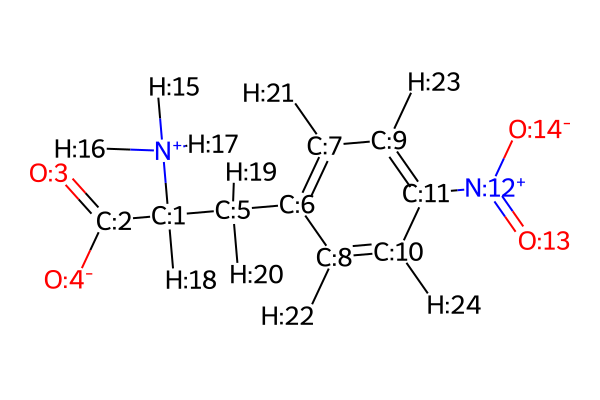

In [170]:
mol = 'L_sidechain_copy/PPN/PPN.mol2'
mol_dict = file_opener(mol, sanitize=True, verbose = False)
(name, chem), = mol_dict.items()
chem = pt.renumber_amino_acid_atoms(chem)
chem_dict[name] = chem
pt.draw_mol_with_atom_index(chem)

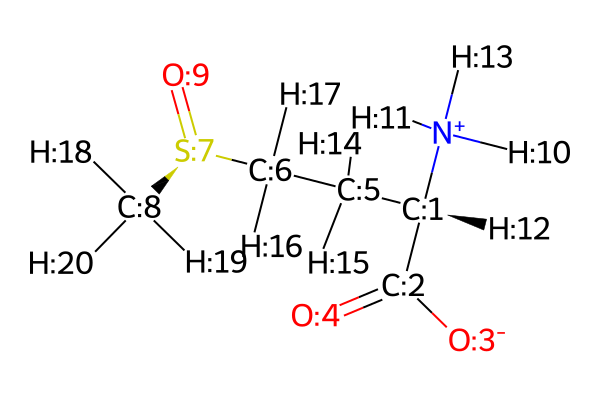

In [120]:
mol = 'L_sidechain_copy/MHO/MHO.mol2'
mol_dict = file_opener(mol, sanitize=True, verbose = False)
(name, chem), = mol_dict.items()
chem = pt.renumber_amino_acid_atoms(chem)
chem_dict[name] = chem
pt.draw_mol_with_atom_index(chem)

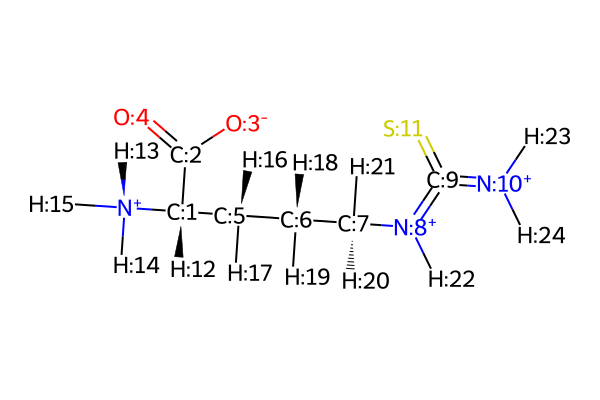

In [57]:
pt.draw_mol_with_atom_index(chem_dict["THIC"])

In [15]:
mol_dict['0AF']

NameError: name 'mol_dict' is not defined

In [60]:
test_mol
name = Path(test_mol[0]).stem
extension = Path(test_mol[0]).suffix.lower()

In [61]:
extension

'.smi'

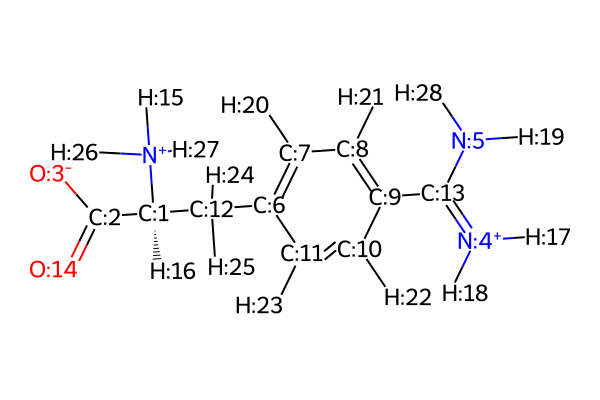

In [41]:
mod = pt.mol2_to_chem('0BN.mol2')
# rn_mod = pt.renumber_amino_acid_atoms(mod['0BN'],smart_ref='[NH3+][CH][C]([O])[O]')
pt.draw_mol_with_atom_index(mod["0BN"])

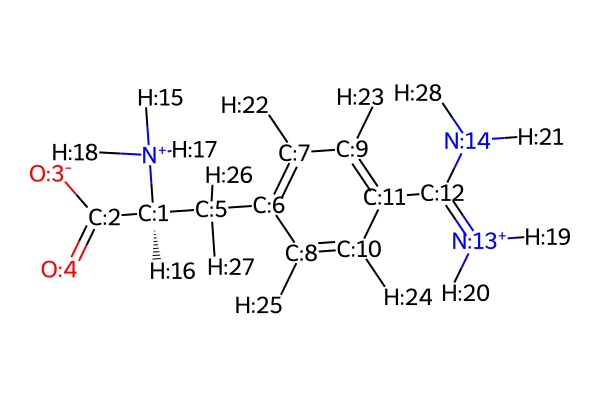

In [36]:
mod = pt.mol2_to_chem('0BN.mol2')
rn_mod = pt.renumber_amino_acid_atoms(mod['0BN'],smart_ref='[NH3+][CH][C]([O])')
pt.draw_mol_with_atom_index(rn_mod)

In [ ]:
pt.mol2_to_chem('0BN.mol2')

In [ ]:
path_to_hdb = 'amber14sb_parmbsc1_cufix.ff/aminoacids.hdb'
hdb_file = []
with open(path_to_hdb, 'r') as hdb:
    for line in hdb:
        hdb_file.append(line)


save_path = f'{PTM_name}/force_field_files/aminoacids.hdb'
with open (save_path, 'w') as dat:
    dat.writelines(add_hdb+hdb_file)